<a href="https://colab.research.google.com/github/r-karra/learn-quantum-computing/blob/main/Use%20a%20quantum%20computer%20today-IBM/build-and-run-your-first-quantum-program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: Build and run your first quantum program
description: A hands-on guide to running the "Hello World" quantum circuit
---



# Build and run your first quantum program

## Introduction

In the following video, Olivia Lanes steps you through the content in this lesson. Alternatively, you can open the [YouTube video](https://youtu.be/vSFv_i_FAXg?si=eGOvZ4AuPclZGTqJ) for this lesson in a separate window.

<IBMVideo id="134769813" title="In this video, Olivia Lanes describes how to install Qiskit and write your first quantum program." />

Welcome to *Use a quantum computer today*! The goal of this course is for you to run code on a real quantum computer in the shortest time possible, with no prior background required. Let's get started.

This first lesson is a gentle, hands-on introduction to quantum computing that works for curious beginners and busy leaders alike. You'll learn about quantum circuits and write a small quantum program that creates **entanglement**, and run it on a real IBM® quantum computer. You also have the option to run the same program on a simulator, should you choose to skip running on a real quantum computer.

You can run this notebook from top to bottom in a fresh Google Colab runtime, or run locally.

### Set up

To run this notebook in Google Colab, you'll need a **Google account** so you can open notebooks and execute cells in the browser.

To run on a real IBM quantum computer, you'll also need a (free) [**IBM Quantum® Platform account**](/signin?redirectTo=%2F). You can open an instance using the Open Plan to get 10 minutes of quantum processor unit (QPU) time per 28-day rolling window, which actually is quite a lot! *If you have trouble with your account, see the [Support page](/docs/guides/support).*

You can also run this notebook locally after installing Qiskit by following the instructions on [**IBM Quantum Platform**](/docs/guides/install-qiskit).

#### Installation and imports

In Colab, we install dependencies inside the notebook so everyone runs the same tools. The next cell installs Qiskit with the [visualization module](/docs/api/qiskit/visualization) plus two add-ons: **Aer** (fast simulators) and the **IBM Runtime** client (for quantum computer runs).

Next, we have a number of imports. The `QuantumCircuit` class is where we define our quantum bits, or qubits, and define operations on those qubits. This is our first quantum term: a **qubit** is the basic building block of quantum computation, just as a bit is the building block of classical computation. We'll learn more about the special properties of qubits as we create our circuit. Next, `plot_histogram` will be used to visualize the results of our quantum circuit. `AerSimulator`, allows us to simulate the quantum circuit on a classical computer. But simulators cannot run quantum circuits at the same scale as real quantum computers; that's why we need real quantum computers. This can be helpful for testing, debugging, or educational purposes; or if you've exhausted your 10 free minutes of QPU time. The `preset_passmanagers` help optimize the circuits to run efficiently on hardware, which becomes really important as our circuits become more complex. `Sampler` and `QiskitRuntimeService` are necessary to actually run the circuit on the quantum computer. More on this later.



In [ ]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService




Next we'll do a quick environment check. We confirm versions and confirm imports.

If anything fails here, it's usually a dependency install issue; fixing it now prevents confusing errors later.



In [ ]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.13
qiskit: 2.3.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.46.1


## A brief side quest: use the Composer

Before we write code, it's helpful to see circuits visually. IBM Quantum **Composer** lets you build circuits by dragging gates onto wires. It's a great way to learn what a circuit is doing without getting distracted by syntax.

Open the Composer [here](/composer).

Once it loads, launch the guided tutorial from the menu: **Help | Build your first circuit**. Work through it at your own pace. As you go, pay attention to how each gate changes what you expect to measure.

The tutorial steps through building the "Hello World" circuit. It's visualized in what is called a circuit diagram, where the qubits are represented by horizontal lines and the gates acting on those qubits are represented by boxes or other symbols on the lines. This circuit introduces us to a few key features of qubits and quantum computers:

First, the red box labeled "H" is a Hadamard gate, which creates a **superposition state** of qubit 0. Unlike a bit, which can only be in the state 1 or 0, a qubit state can include both possibilities at once, with certain weights (called amplitudes) attached to each. Superposition doesn't mean you'll ever see both results in one measurement; it means the state is set up so that either outcome can happen when you measure.

Second, the circles and vertical line connecting the two qubits is a CNOT gate, which generates **entanglement** between the two qubits. Entanglement is a special kind of link between qubits. When qubits are entangled, the outcomes of measurements can be strongly correlated in a way that doesn't match what we'd expect from ordinary independent coin flips, or from any classical correlation. When two qubits are entangled, measuring one will instantaneously tell you the outcome of measuring the other.

Another key idea you'll see in the tutorial is **shots**. Because **measurement** is the moment a qubit stops behaving like a quantum state and gives you a classical readout, a superposition state will probabilistically collapse to either a 0 or a 1 when it's measured. So, to learn about that superposition, you need to measure it many times by running the same circuit to accumulate statistics. These are called shots.

#### Check your understanding

Think about each question below, then click to reveal the answer.

Can you see a superposition directly from a single measurement?

<Accordion>
  <AccordionItem title="Answer">
    No. A single measurement always returns a classical value: either 0 or 1. The "mixture" idea shows up only in the statistics you see after many runs, also called shots.
  </AccordionItem>
</Accordion>

In plain language, what does entanglement give you?

<Accordion>
  <AccordionItem title="Answer">
    It gives you linked outcomes. Measuring one qubit tells you something about the other. This link is stronger than independent randomness and stronger than any purely classical correlation or shared randomness can explain.
  </AccordionItem>
</Accordion>

If a qubit is in a superposition, what do you see in a single measurement, and why do you need many shots?

<Accordion>
  <AccordionItem title="Answer">
    In a single measurement you see only one classical result: either 0 or 1. You need many shots because the "superposition" shows up as a probability distribution, which you can only estimate by collecting statistics over repeated runs.
  </AccordionItem>
</Accordion>

Look at the measurement histogram of your Hello World circuit in the Composer. What do you see? Why is this a signature of entanglement?

<Accordion>
  <AccordionItem title="Answer">
    It shows you a 50% chance of being in the state $|00\rangle$ and a 50% chance of being in the state $|11\rangle$. This means that if you measure one to be 0, the other will be 0 and if you measure one to be 1, the other will also be 1. This is a correlation between the two qubits that can be explained by entanglement.
  </AccordionItem>
</Accordion>



### Create and run a quantum program using Qiskit

Okay, back to coding. We're going to generate the same entangled state as we did in Composer (called the **$\Phi^+$ (phi-plus) Bell state**) but this time, we'll write the code by hand. We need to build this skill because as we scale to more qubits and more complicated circuits, the Composer won't be able to help us.

To build the Bell state circuit, we use an $H$ (Hadamard) gate to put the first qubit into an equal superposition. Then we apply a $CX$ (controlled-NOT) gate, which entangles the two states together. The two qubits are now correlated in a way that has no classical equivalent.



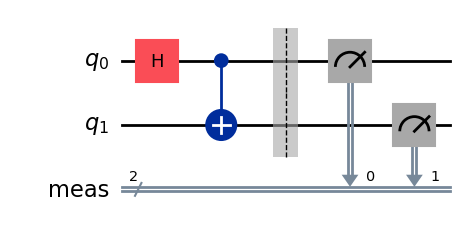

In [ ]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

bell.draw("mpl")

#### Helper function for running circuits

Now let's define a helper function that handles the process of running a quantum circuit and retrieving measurement results. This function takes care of transpiling the circuit to match the backend's instruction set, running it through a `Sampler` primitive, and extracting the counts from the results.



In [ ]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

#### Run on a QPU and visualize results

Finally, we run the circuit on an IBM quantum processing unit (QPU) in the cloud for 1000 shots and plot the results. IBM QPUs are physical systems that can pick up noise, so gates are slightly imperfect, measurements can be wrong sometimes, and device calibration drifts over time.

Running on real quantum computers also introduces practical considerations. Jobs can sit in a queue, because many people may be using the same device. You also have to choose a shot count that balances statistical considerations (more shots equals a higher signal-to-noise ratio) with time/cost constraints.

Follow the instructions in the code comments of the next cell. After running the cell, you should see a histogram with approximately equal counts for the $00$ and $11$ bitstrings, with some occurrences of $01$ or $10$ due to noise. The following cell in this notebook runs the same circuit on a simulator, should you choose to skip running on a QPU.



In [ ]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

# Retrieve the token from Colab Secrets
try:
    api_token = userdata.get('IBMQ_TOKEN')

    # Connect to the service
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=api_token
    )

    try:
        # Try to find a real QPU first
        backend = service.least_busy(operational=True, simulator=False)
        print(f"Successfully connected to: {backend.name}")
    except Exception:
        print("No real QPU found or available in your plan. Falling back to AerSimulator.")
        backend = AerSimulator()
        print(f"Using: {backend.name}")

except userdata.SecretNotFoundError:
    print("Error: 'IBMQ_TOKEN' not found in Secrets. Please add it via the 🔑 icon in the sidebar.")
except Exception as e:
    print(f"An error occurred during authentication: {e}")

qiskit_runtime_service._discover_account:WARNING:2026-04-16 10:07:47,515: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service._discover_backends_from_instance:WARNING:2026-04-16 10:07:49,563: Invalid instance crn:v1:bluemix:public:quantum-computing:us-east:a/b1880c0f2b284a7b9206a8de1bbd51f8:39e23595-42ac-468b-ab60-21b5cc9f19fc::
qiskit_runtime_service.__init__:WARNING:2026-04-16 10:07:49,564: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: qiskit_summerSchool2025. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-16 10:07:49,775: Loading instance: qiskit_summerSchool2025, plan: open


No real QPU found or available in your plan. Falling back to AerSimulator.
Using: aer_simulator


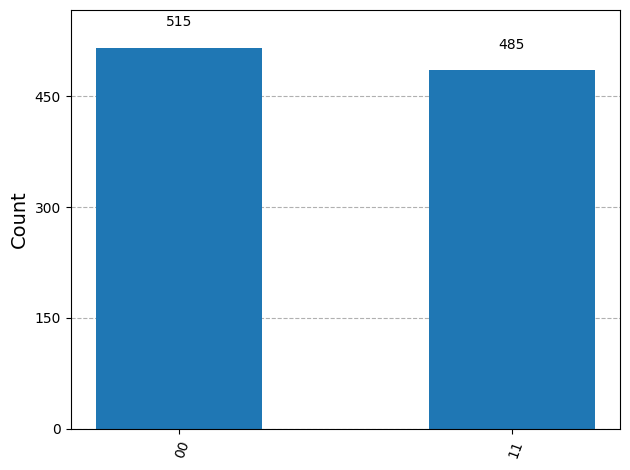

In [ ]:
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

#### Run on a simulator and visualize results

A simulator is a "perfect world" version of quantum computing. Here we run the circuit on a simulator for 1000 shots and plot the results. You should see approximately equal counts for the $00$ and $11$ states, with no occurrences of $01$ or $10$, which is the signature of the Bell state's perfect correlation.



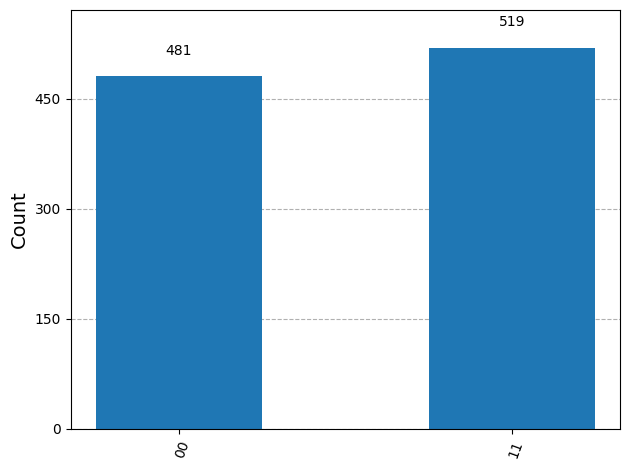

In [ ]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)

plot_histogram(counts)

#### Check your understanding

What are the two gates that create the Bell state here?

<Accordion>
  <AccordionItem title="Answer">
    An H gate on qubit 0, followed by a CX gate with qubit 0 as control and qubit 1 as target.
  </AccordionItem>
</Accordion>

On an ideal simulator, which two bitstrings should dominate the histogram?

<Accordion>
  <AccordionItem title="Answer">
    00 and 11 should dominate.
  </AccordionItem>
</Accordion>

Why wouldn't a perfect simulator always have the exact same number of 00 counts as 11 counts?

<Accordion>
  <AccordionItem title="Answer">
    Even though a simulator is "perfect" and leads to a perfect Bell state, it is still simulating an inherently random process, so statistical fluctuations will still occur. It's like flipping a coin 1000 times: even if there is an exact 50-50 chance of the coin landing on heads or tails, that doesn't mean you'll always get exactly 500 instances of heads and 500 of tails.
  </AccordionItem>
</Accordion>

Why might a real quantum computer show some 01 or 10 results even though the simulator didn't?

<Accordion>
  <AccordionItem title="Answer">
    Because real devices have noise. Gates and measurements are not perfect, and that can introduce occasional errors.
  </AccordionItem>
</Accordion>

What is one practical difference between simulators and real quantum computers besides noise?

<Accordion>
  <AccordionItem title="Answer">
    Quantum computers can involve queue time, limited availability, and device-specific constraints that affect how circuits run.
  </AccordionItem>
</Accordion>



### Conclusion

We started by setting up Qiskit in a fresh Colab environment, which is exactly how many real-world notebook workflows begin. We followed that with a journey into quantum computing using the Composer. We then built a simple two-qubit circuit that produces the $\Phi^+$ Bell state and used repeated sampling and visualized the entanglement as a correlation in the qubit measurement histogram. We also saw how real quantum computers introduce noise and errors.

#### Learning objective

Now that we've walked through how to create the $\Phi^+$ Bell state, see if you can edit the code to create one of the other three [Bell states](https://en.wikipedia.org/wiki/Bell_state#Bell_basis). In particular, the $\Psi^-$ state will be used in an upcoming lesson, so if you figure out how to create it, you'll be ahead of the game.



### The Four Bell States

The Bell basis consists of four specific maximally entangled states for two qubits:

1.  **Phi-plus:**
    $$\displaystyle |\Phi ^{+}\rangle ={\frac {1}{\sqrt {2}}}{\big (}|0\rangle _{A}\otimes |0\rangle _{B}+|1\rangle _{A}\otimes |1\rangle _{B}{\big )}\qquad (1)$$

2.  **Phi-minus:**
    $$\displaystyle |\Phi ^{-}\rangle ={\frac {1}{\sqrt {2}}}{\big (}|0\rangle _{A}\otimes |0\rangle _{B}-|1\rangle _{A}\otimes |1\rangle _{B}{\big )}\qquad (2)$$

3.  **Psi-plus:**
    $$\displaystyle |\Psi ^{+}\rangle ={\frac {1}{\sqrt {2}}}{\big (}|0\rangle _{A}\otimes |1\rangle _{B}+|1\rangle _{A}\otimes |0\rangle _{B}{\big )}\qquad (3)$$

4.  **Psi-minus:**
    $$\displaystyle |\Psi ^{-}\rangle ={\frac {1}{\sqrt {2}}}{\big (}|0\rangle _{A}\otimes |1\rangle _{B}-|1\rangle _{A}\otimes |0\rangle _{B}{\big )}\qquad (4)$$

In our circuit, we created the $|\Phi ^{+}\rangle$ state using a Hadamard and a CNOT gate.

© IBM Corp., 2017-2026

In [ ]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer

#Core qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

#IBM runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

In [ ]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python: ", sys.version.split()[0])
print("qiskit: ", qiskit.__version__)
print("qiskit-aer: ", qiskit_aer.__version__)
print("qiskit-ibm-runtime: ", qiskit_ibm_runtime.__version__)

Python:  3.12.13
qiskit:  2.4.0
qiskit-aer:  0.17.2
qiskit-ibm-runtime:  0.46.1


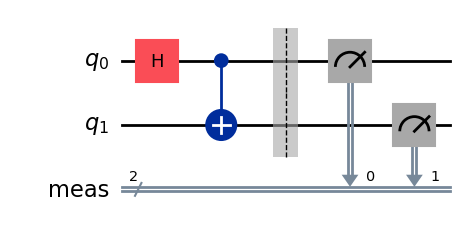

In [ ]:
# --- Build the bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

In [ ]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
  pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
  isa_circuit = pm.run(circuit)

  sampler = Sampler(mode=backend)
  job = sampler.run([isa_circuit], shots=shots)
  result = job.result()

  return result[0].data.meas.get_counts()

In [ ]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# Retrieve the token from Colab Secrets
try:
    api_token = userdata.get('IBMQ_TOKEN')
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=api_token
    )
    print("IBM Quantum service initialized successfully.")
except userdata.SecretNotFoundError:
    print("Error: 'IBMQ_TOKEN' not found in Colab Secrets. Please add it via the 🔑 icon in the sidebar.")
except Exception as e:
    print(f"An error occurred during authentication: {e}")

qiskit_runtime_service._discover_account:WARNING:2026-04-17 09:21:14,297: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-17 09:21:17,739: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


IBM Quantum service initialized successfully.


In [ ]:
# backend = service.least_busy(operational=True, simulator=False, min_num_quits=12)
backend = service.backend("ibm_kingston")
print(f"Selected backend: {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-04-17 09:29:03,060: Using instance: open-instance, plan: open


Selected backend: ibm_kingston


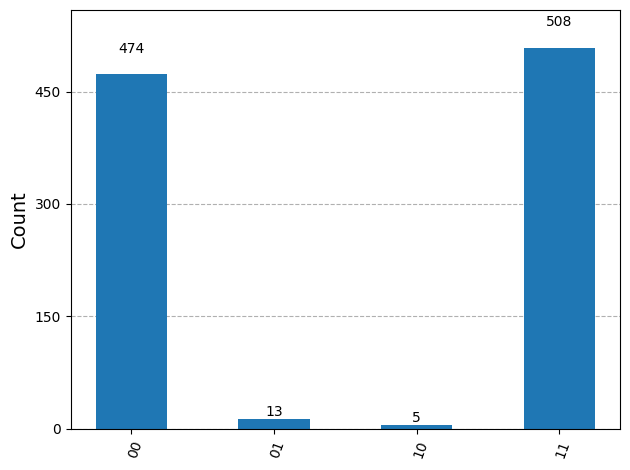

In [ ]:
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

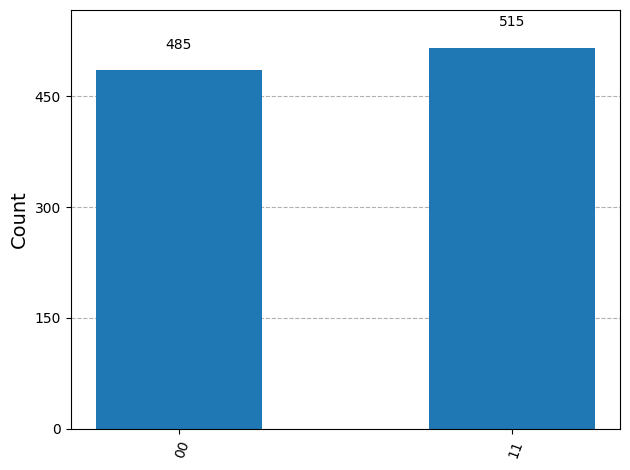

In [ ]:
backend=AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

In [ ]:
# --- Build the Phi-minus circuit ---
phi_minus_circuit = QuantumCircuit(2)
phi_minus_circuit.h(0)
phi_minus_circuit.cx(0, 1)
phi_minus_circuit.z(0) # Apply a Z-gate to qubit 0 to introduce the phase for Phi-minus
phi_minus_circuit.measure_all() # creates a classical register named "meas"

# Draw the circuit
print("Phi-minus Circuit:")
phi_minus_circuit.draw("mpl")

# Run the circuit on an AerSimulator and get counts
backend = AerSimulator()
phi_minus_counts = run_circuit_and_get_counts(phi_minus_circuit, backend, shots=1000)

# Plot the histogram of the results
plot_histogram(phi_minus_counts, title="Measurement results for Phi-minus state")

In [ ]:
# --- Build the phi-minus circuit ---
phi_minus_circuit = QuantumCircuit(2)
phi_minus_circuit.h(0)
phi_minus_circuit.cx(0, 1)
phi_minus_circuit.z(0) # apply a Z-gate to qubit 0 to introduce the phase for phi-minus
phi_minus_circuit.measure_all() # creates a classical register named "meas"

phi-minus-circuit: 


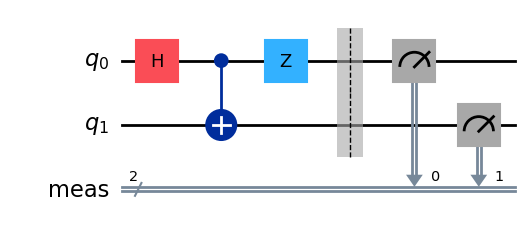

In [ ]:
# Draw the circuit
print('phi-minus-circuit: ')
phi_minus_circuit.draw('mpl')

In [ ]:
# Run the circuit on an AerSimulator and get counts
backend = AerSimulator()
phi_minus_counts = run_circuit_and_get_counts(phi_minus_circuit, backend, shots=1000)


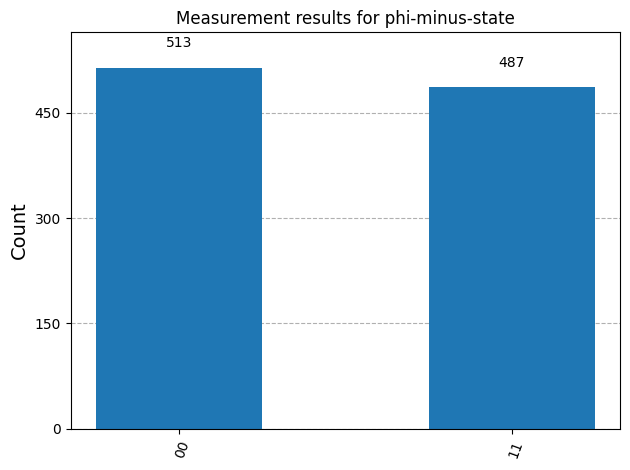

In [ ]:
plot_histogram(phi_minus_counts, title= "Measurement results for phi-minus-state")

In [ ]:
# Helper function for running circuits

def run_circuit_and_get_counts(circuit, backend, shots=1000):
  pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
  isa_circuit = pm.run(circuit)
  sampler = Sampler(mode=backend)
  job = sampler.run([isa_circuit], shots=shots)
  result = job.result()
  return result[0].data.meas.get_counts()

In [ ]:
# backend = service.backend("ibm_kingston")
# print(f"Selected backend: {backend.name}")

In [ ]:
# counts = run_circuit_and_get_counts(phi_minus_circuit, backend, shots=1000)
# plot_histogram(counts)

Psi-plus Circuit:


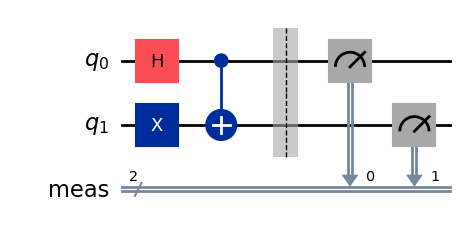

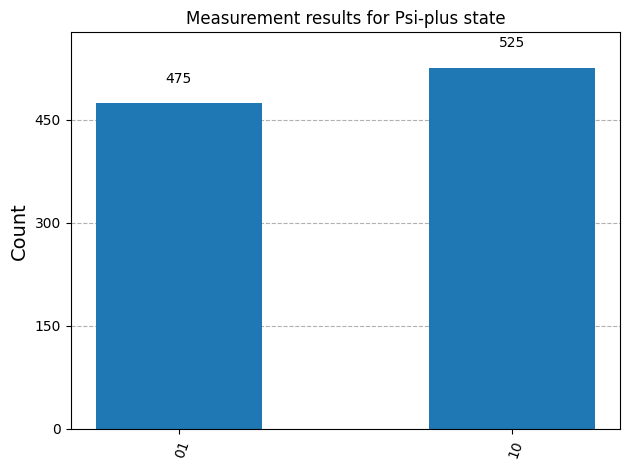

In [ ]:
# --- Build the Psi-plus circuit ---
psi_plus_circuit = QuantumCircuit(2)
psi_plus_circuit.x(1) # Initialize qubit 1 to |1>
psi_plus_circuit.h(0)
psi_plus_circuit.cx(0, 1)
psi_plus_circuit.measure_all()

print("Psi-plus Circuit:")
display(psi_plus_circuit.draw("mpl"))

# Run the Psi-plus circuit on an AerSimulator and get counts
backend = AerSimulator()
psi_plus_counts = run_circuit_and_get_counts(psi_plus_circuit, backend, shots=1000)

# Plot the histogram of the results for Psi-plus
plot_histogram(psi_plus_counts, title="Measurement results for Psi-plus state")




Psi-minus Circuit:


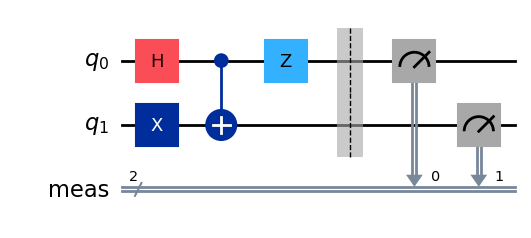

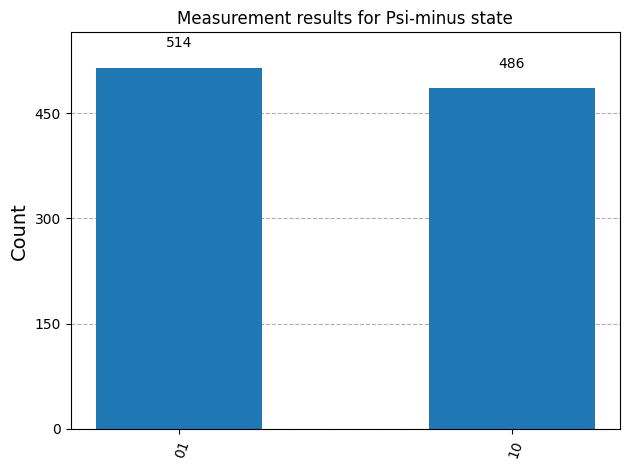

In [ ]:
# --- Build the Psi-minus circuit ---
psi_minus_circuit = QuantumCircuit(2)
psi_minus_circuit.x(1) # Initialize qubit 1 to |1>
psi_minus_circuit.h(0)
psi_minus_circuit.cx(0, 1)
psi_minus_circuit.z(0) # Apply a Z-gate to qubit 0 to introduce the phase for Psi-minus
psi_minus_circuit.measure_all()

print("\nPsi-minus Circuit:")
display(psi_minus_circuit.draw("mpl"))

# Run the Psi-minus circuit on an AerSimulator and get counts
psi_minus_counts = run_circuit_and_get_counts(psi_minus_circuit, backend, shots=1000)

# Plot the histogram of the results for Psi-minus
plot_histogram(psi_minus_counts, title="Measurement results for Psi-minus state")

In [2]:
!uv pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer

Using Python 3.12.13 environment at: /usr
Resolved 49 packages in 1.87s
Prepared 13 packages in 843ms
Installed 13 packages in 47ms
 + ibm-cloud-sdk-core==3.24.4
 + ibm-platform-services==0.75.0
 + ibm-quantum-schemas==0.7.20260419
 + pybase64==1.4.3
 + pylatexenc==2.10
 + pyspnego==0.12.1
 + qiskit==2.4.0
 + qiskit-aer==0.17.2
 + qiskit-ibm-runtime==0.46.1
 + requests-ntlm==1.3.0
 + rustworkx==0.17.1
 + samplomatic==0.18.0
 + stevedore==5.7.0


In [5]:
from typing_extensions import runtime
#qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

#IBM runtime imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


In [7]:
import os
import sys
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print('Python:', sys.version.split()[0])
print('qiskit', qiskit.__version__)
print('qiskit_aer', qiskit_aer.__version__)
print('qiskit-ibm-runtime', qiskit_ibm_runtime.__version__)

Python: 3.12.13
qiskit 2.4.0
qiskit_aer 0.17.2
qiskit-ibm-runtime 0.46.1


#Phi-plus

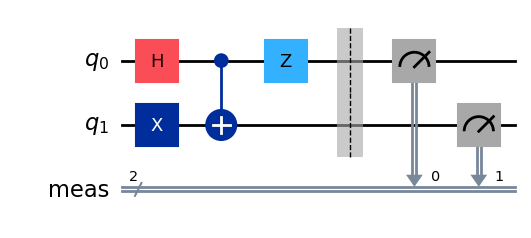

In [20]:
#Phi-Plus
# bell = QuantumCircuit(2)
# bell.h(0)
# bell.cx(0, 1)
# bell.measure_all()
# bell.draw('mpl')


# #Phi-Minus
# bell = QuantumCircuit(2)
# bell.h(0)
# bell.cx(0, 1)
# bell.z(0)
# bell.measure_all()
# bell.draw('mpl')

#Psi-Plus

# bell = QuantumCircuit(2)
# bell.x(1)
# bell.h(0)
# bell.cx(0, 1)
# bell.measure_all()
# bell.draw('mpl')

#Psi-Minus

bell = QuantumCircuit(2)
bell.x(1)
bell.h(0)
bell.cx(0, 1)
bell.z(0)
bell.measure_all()
bell.draw('mpl')

In [21]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
  pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
  isa_circuit = pm.run(circuit)
  sampler = Sampler(mode=backend)
  job = sampler.run([isa_circuit], shots=shots)
  result = job.result()
  return result[0].data.meas.get_counts()

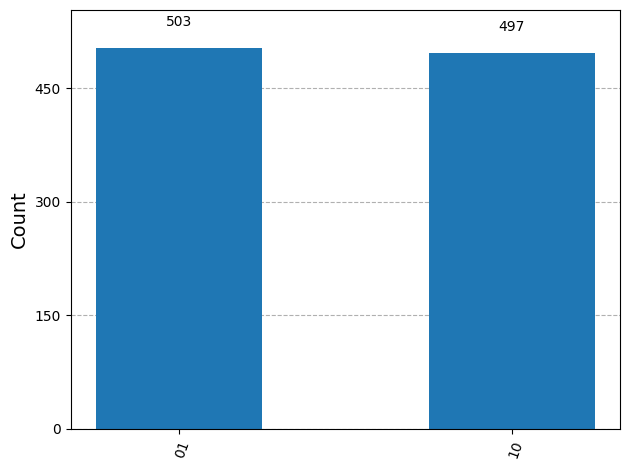

In [22]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)
